In [1]:
import pandas as pd

df = pd.read_csv('src/data/quali-results.csv')
df

,DriverId,TeamName,Q1,Q2,Q3,Position,circuit_id,round_number,year_id
0,hamilton,Mercedes,82.824,82.051,81.164,1.0,albert_park,1,2018
1,raikkonen,Ferrari,83.096,82.507,81.828,2.0,albert_park,1,2018
2,vettel,Ferrari,83.348,81.944,81.838,3.0,albert_park,1,2018
3,max_verstappen,Red Bull Racing,83.483,82.416,81.879,4.0,albert_park,1,2018
4,ricciardo,Red Bull Racing,83.494,82.897,82.152,5.0,albert_park,1,2018
...,...,...,...,...,...,...,...,...,...
3454,hamilton,Ferrari,83.394,NaN,NaN,16.0,yas_marina,24,2025
3455,albon,Williams,83.416,NaN,NaN,17.0,yas_marina,24,2025
3456,hulkenberg,Kick Sauber,83.450,NaN,NaN,18.0,yas_marina,24,2025
3457,gasly,Alpine,83.468,NaN,NaN,19.0,yas_marina,24,2025


In [2]:
def range_by_round(df, session):
    valid_times = df.dropna(subset=[session]).copy()

    max_position_idx = valid_times.groupby(["year_id", "circuit_id"])["Position"].idxmax()
    max_position_times = (
        valid_times.loc[max_position_idx, ["year_id", "circuit_id", "Position", session]]
        .rename(
            columns={
                "Position": f"{session}_MaxPosition",
                session: f"{session}_MaxPositionTime",
            }
        )
    )

    p1_times = (
        valid_times[valid_times["Position"].eq(1)]
        [["year_id", "circuit_id", session]]
        .rename(columns={session: f"{session}_P1"})
    )

    session_range = pd.merge(p1_times, max_position_times, on=["year_id", "circuit_id"], how="inner")
    session_range[f"{session}Range"] = (
        session_range[f"{session}_MaxPositionTime"] - session_range[f"{session}_P1"]
    )

    return session_range.sort_values(["year_id", "circuit_id"]).reset_index(drop=True)


q1_range_by_round = range_by_round(df, "Q1")
q1_range_by_round


,year_id,circuit_id,Q1_P1,Q1_MaxPosition,Q1_MaxPositionTime,Q1Range
0,2018,albert_park,82.824,20.0,85.295,2.471
1,2018,americas,94.130,20.0,95.735,1.605
2,2018,bahrain,89.060,20.0,91.503,2.443
3,2018,baku,102.762,19.0,117.354,14.592
4,2018,catalunya,77.633,19.0,80.225,2.592
...,...,...,...,...,...,...
168,2025,suzuka,87.943,20.0,89.271,1.328
169,2025,vegas,115.473,20.0,117.115,1.642
170,2025,villeneuve,72.075,20.0,72.667,0.592
171,2025,yas_marina,82.877,20.0,83.890,1.013


In [3]:
q2_range_by_round = range_by_round(df, "Q2")
q2_range_by_round


,year_id,circuit_id,Q2_P1,Q2_MaxPosition,Q2_MaxPositionTime,Q2Range
0,2018,albert_park,82.051,15.0,84.786,2.735
1,2018,americas,93.480,12.0,94.732,1.252
2,2018,bahrain,88.341,14.0,90.525,2.184
3,2018,baku,103.015,15.0,104.759,1.744
4,2018,catalunya,77.166,15.0,79.098,1.932
...,...,...,...,...,...,...
168,2025,suzuka,87.502,15.0,88.000,0.498
169,2025,vegas,111.379,15.0,113.683,2.304
170,2025,villeneuve,71.570,15.0,72.634,1.064
171,2025,yas_marina,82.752,15.0,83.097,0.345


In [4]:
q3_range_by_round = range_by_round(df, "Q3")
q3_range_by_round


,year_id,circuit_id,Q3_P1,Q3_MaxPosition,Q3_MaxPositionTime,Q3Range
0,2018,albert_park,81.164,9.0,83.577,2.413
1,2018,americas,92.237,10.0,94.594,2.357
2,2018,bahrain,87.958,10.0,89.986,2.028
3,2018,baku,101.498,10.0,103.351,1.853
4,2018,catalunya,76.173,10.0,77.835,1.662
...,...,...,...,...,...,...
168,2025,suzuka,86.983,10.0,87.867,0.884
169,2025,vegas,107.934,10.0,111.540,3.606
170,2025,villeneuve,70.899,10.0,71.907,1.008
171,2025,yas_marina,82.207,9.0,83.072,0.865


In [43]:
range_df = pd.merge(q1_range_by_round, q2_range_by_round, on=["year_id", "circuit_id"], how="outer")
range_df = pd.merge(range_df, q3_range_by_round, on=["year_id", "circuit_id"], how="outer")
range_df = range_df[
    ~((range_df["year_id"] == 2020) & (range_df["circuit_id"] == "bahrain"))
]
range_df = range_df[["year_id", "circuit_id", "Q1Range", "Q2Range", "Q3Range"]]
range_df

,year_id,circuit_id,Q1Range,Q2Range,Q3Range
0,2018,albert_park,2.471,2.735,2.413
1,2018,americas,1.605,1.252,2.357
2,2018,bahrain,2.443,2.184,2.028
3,2018,baku,14.592,1.744,1.853
4,2018,catalunya,2.592,1.932,1.662
...,...,...,...,...,...
192,2025,suzuka,1.328,0.498,0.884
193,2025,vegas,1.642,2.304,3.606
194,2025,villeneuve,0.592,1.064,1.008
195,2025,yas_marina,1.013,0.345,0.865


In [44]:
# range_df.groupby("year_id")[["Q1Range", "Q2Range", "Q3Range"]].mean().reset_index()
range_df[["year_id", "circuit_id", "Q2Range"]]

,year_id,circuit_id,Q2Range
0,2018,albert_park,2.735
1,2018,americas,1.252
2,2018,bahrain,2.184
3,2018,baku,1.744
4,2018,catalunya,1.932
...,...,...,...
192,2025,suzuka,0.498
193,2025,vegas,2.304
194,2025,villeneuve,1.064
195,2025,yas_marina,0.345


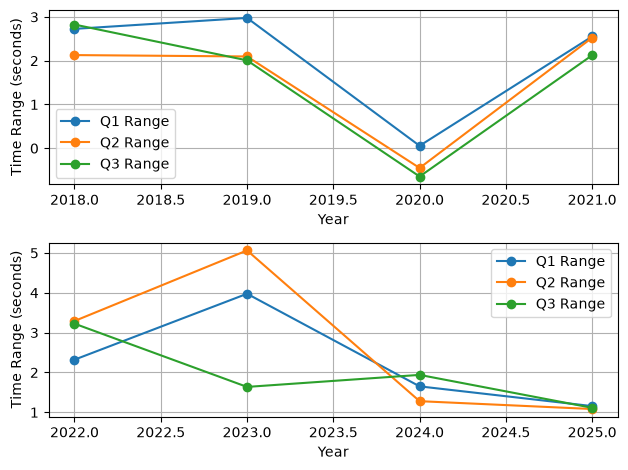

In [45]:
import matplotlib.pyplot as plt

# circuit_id = 'yas_marina'
data_df = range_df

turbo_hybrd = data_df[data_df['year_id'] < 2022].groupby('year_id')[['Q1Range', 'Q2Range', 'Q3Range']].mean().reset_index()
ground_effect = data_df[data_df['year_id'] >= 2022].groupby('year_id')[['Q1Range', 'Q2Range', 'Q3Range']].mean().reset_index()

fig, ax = plt.subplots(2, 1)
ax[0].plot(turbo_hybrd['year_id'], turbo_hybrd['Q1Range'], marker='o', label='Q1 Range')
ax[0].plot(turbo_hybrd['year_id'], turbo_hybrd['Q2Range'], marker='o', label='Q2 Range')
ax[0].plot(turbo_hybrd['year_id'], turbo_hybrd['Q3Range'], marker='o', label='Q3 Range')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Time Range (seconds)')
ax[0].legend()
ax[0].grid()

ax[1].plot(ground_effect['year_id'], ground_effect['Q1Range'], marker='o', label='Q1 Range')
ax[1].plot(ground_effect['year_id'], ground_effect['Q2Range'], marker='o', label='Q2 Range')
ax[1].plot(ground_effect['year_id'], ground_effect['Q3Range'], marker='o', label='Q3 Range')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Time Range (seconds)')
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()